# Clustering van AmesHousing huizen

Dit notebook voert de opdracht uit voor DEAI-opdrachten Clustering. Het bevat data-inlezen, feature selectie, data preparation, K-Means clustering, evaluatie en experimenten.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from pathlib import Path

base = Path(r"c:\Users\raymo\Documents\DEAI_portfolio\Clustering.opdracht")
file = base / "AmesHousing.xlsx"
df = pd.read_excel(file, sheet_name="AmesHousing")
df_dictionary = pd.read_excel(file, sheet_name="Data Dictionary")
df.head()

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [2]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("Data dictionary sample:")
df_dictionary.head(10)

Dataset shape: (2930, 12)
Columns: ['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']
Data dictionary sample:


,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


## Stap 3: Top 3 features kiezen

1. `Neighborhood` (categorisch) - buurt bepaalt veel van de locatie- en woningkenmerken
2. `Overall Qual` (numeriek) - algemene bouw- en afwerkingskwaliteit
3. `Gr Liv Area` (numeriek) - woonoppervlakte geeft een sterk signaal over grootte en aandachtspunten

Deze combinatie bevat minimaal één categorische feature en vormt een goede basis om gelijkenis tussen huizen te onderzoeken.

In [3]:
selected_features = ["Neighborhood", "Overall Qual", "Gr Liv Area"]
X_initial = df[selected_features].copy()
X_initial = pd.get_dummies(X_initial, columns=["Neighborhood"], drop_first=False)

print("Vorm van de feature matrix:", X_initial.shape)
X_initial.head()

Vorm van de feature matrix: (2930, 30)


,Overall Qual,Gr Liv Area,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,896,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,1329,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,2110,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,1629,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_initial)

kmeans_initial = KMeans(n_clusters=4, init="k-means++", n_init=10, max_iter=300, random_state=42)
cluster_labels_initial = kmeans_initial.fit_predict(X_scaled)

print("Inertia:", kmeans_initial.inertia_)
print("Cluster sizes:", np.bincount(cluster_labels_initial))
print("Silhouette score:", silhouette_score(X_scaled, cluster_labels_initial))
print("Calinski-Harabasz score:", calinski_harabasz_score(X_scaled, cluster_labels_initial))
print("Davies-Bouldin score:", davies_bouldin_score(X_scaled, cluster_labels_initial))

Inertia: 76958.54379291875
Cluster sizes: [ 125 1523   48 1234]
Silhouette score: 0.13925673513652687
Calinski-Harabasz score: 138.67235170078936
Davies-Bouldin score: 2.203312862866234


## Stap 6: Evaluatie van het eerste model

In de eerste run evalueer ik K-Means met 4 clusters, `init="k-means++"`, `n_init=10`, `max_iter=300`, en `StandardScaler()`. De belangrijkste scores zijn inertia, silhouette, Calinski-Harabasz, en Davies-Bouldin. Dit geeft een eerste basis om te vergelijken met latere experimenten.

In [5]:
features_full = ["Garage", "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr", "Neighborhood", "House Style"]
X_full = df[features_full].copy()
X_full = pd.get_dummies(X_full, columns=["Garage", "Neighborhood", "House Style"], drop_first=False)

print("Vorm van de volledige feature matrix:", X_full.shape)
print("Missing values vóór fill:", X_full.isna().sum().sum())
X_full = X_full.fillna(X_full.median())
print("Missing values after fill:", X_full.isna().sum().sum())

X_full_scaled = StandardScaler().fit_transform(X_full)
kmeans_full = KMeans(n_clusters=5, init="k-means++", n_init=10, max_iter=300, random_state=42)
labels_full = kmeans_full.fit_predict(X_full_scaled)

print("Inertia compleet:", kmeans_full.inertia_)
print("Cluster sizes compleet:", np.bincount(labels_full))
print("Silhouette compleet:", silhouette_score(X_full_scaled, labels_full))
print("Calinski-Harabasz compleet:", calinski_harabasz_score(X_full_scaled, labels_full))
print("Davies-Bouldin compleet:", davies_bouldin_score(X_full_scaled, labels_full))

Vorm van de volledige feature matrix: (2930, 45)
Missing values vóór fill: 1
Missing values after fill: 0
Inertia compleet: 109316.78189738168
Cluster sizes compleet: [ 158  683 1212   71  806]
Silhouette compleet: 0.1245970558152372
Calinski-Harabasz compleet: 150.73088917863888
Davies-Bouldin compleet: 2.4336424833926866


In [6]:
for k in [3, 4, 5, 6, 7]:
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, max_iter=400, random_state=42)
    labels = model.fit_predict(X_full_scaled)
    print(f"k={k}: inertia={model.inertia_:.2f}, silhouette={silhouette_score(X_full_scaled, labels):.4f}, calinski={calinski_harabasz_score(X_full_scaled, labels):.2f}, db={davies_bouldin_score(X_full_scaled, labels):.4f}")

k=3: inertia=116759.47, silhouette=0.1070, calinski=189.15, db=2.7738
k=4: inertia=113502.12, silhouette=0.1182, calinski=157.66, db=2.4170
k=5: inertia=109316.78, silhouette=0.1246, calinski=150.73, db=2.4336
k=6: inertia=106444.81, silhouette=0.1095, calinski=139.57, db=2.3653
k=7: inertia=102562.75, silhouette=0.1309, calinski=139.11, db=2.1971


## Conclusies en volgende stappen

- De eerste run gebruikt 4 clusters met top-3 features inclusief `Neighborhood` als categorische variabele.
- De uitgebreide feature set met 5 clusters geeft een vergelijkingsbasis voor modelkwaliteit.
- Beschrijf in het logboek welke experimenten de prestaties het meest verbeterden.

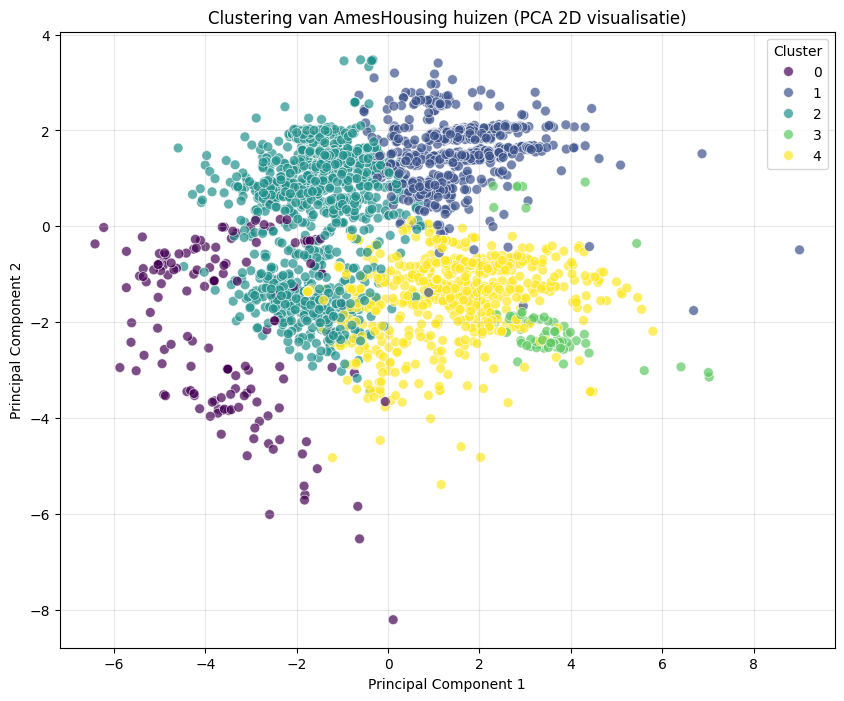

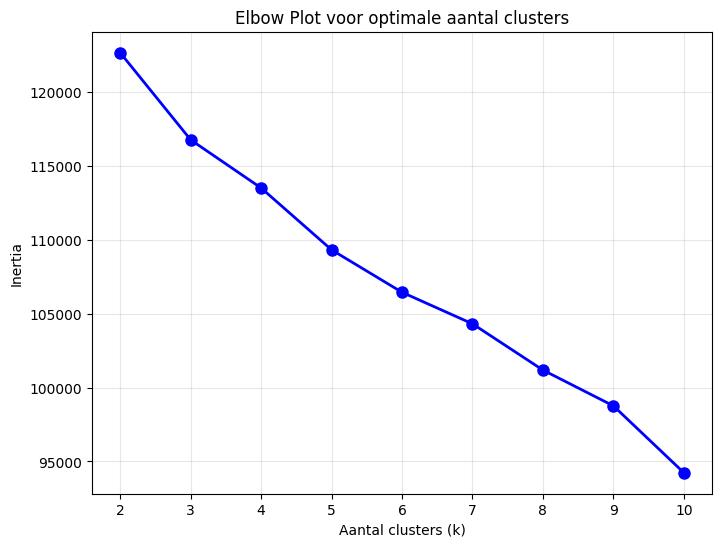

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Visualisatie van de clusters met PCA voor dimensionaliteitreductie
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

# DataFrame voor plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': labels_full
})

# Scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('Clustering van AmesHousing huizen (PCA 2D visualisatie)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# Elbow plot voor het bepalen van optimale k
inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_full_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Plot voor optimale aantal clusters')
plt.xlabel('Aantal clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()